In [6]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *
import pymc3 as pm

WARN: Could not locate executable g77
WARN: Could not locate executable f77
WARN: Could not locate executable ifort
WARN: Could not locate executable ifl
WARN: Could not locate executable f90
WARN: Could not locate executable C:\Program
WARN: Could not locate executable efl
WARN: Could not locate executable gfortran
WARN: Could not locate executable f95
WARN: Could not locate executable g95
WARN: Could not locate executable efort
WARN: Could not locate executable efc
WARN: Could not locate executable flang
WARN: don't know how to compile Fortran code on platform 'nt'


WARNING (theano.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (theano.configdefaults): g++ not detected ! Theano will be unable to execute optimized C-implementations (for both CPU and GPU) and will default to Python implementations. Performance will be severely degraded. To remove this warning, set Theano flags cxx to an empty string.
WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


In [7]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [9]:
d = np.array([0,0,0,1])

In [10]:
def fun_loglike1(pi):
    loglike_indiv = d* np.log(pi) + (1-d) * (np.log(1-pi))
    loglike = np.sum(loglike_indiv)
    return loglike

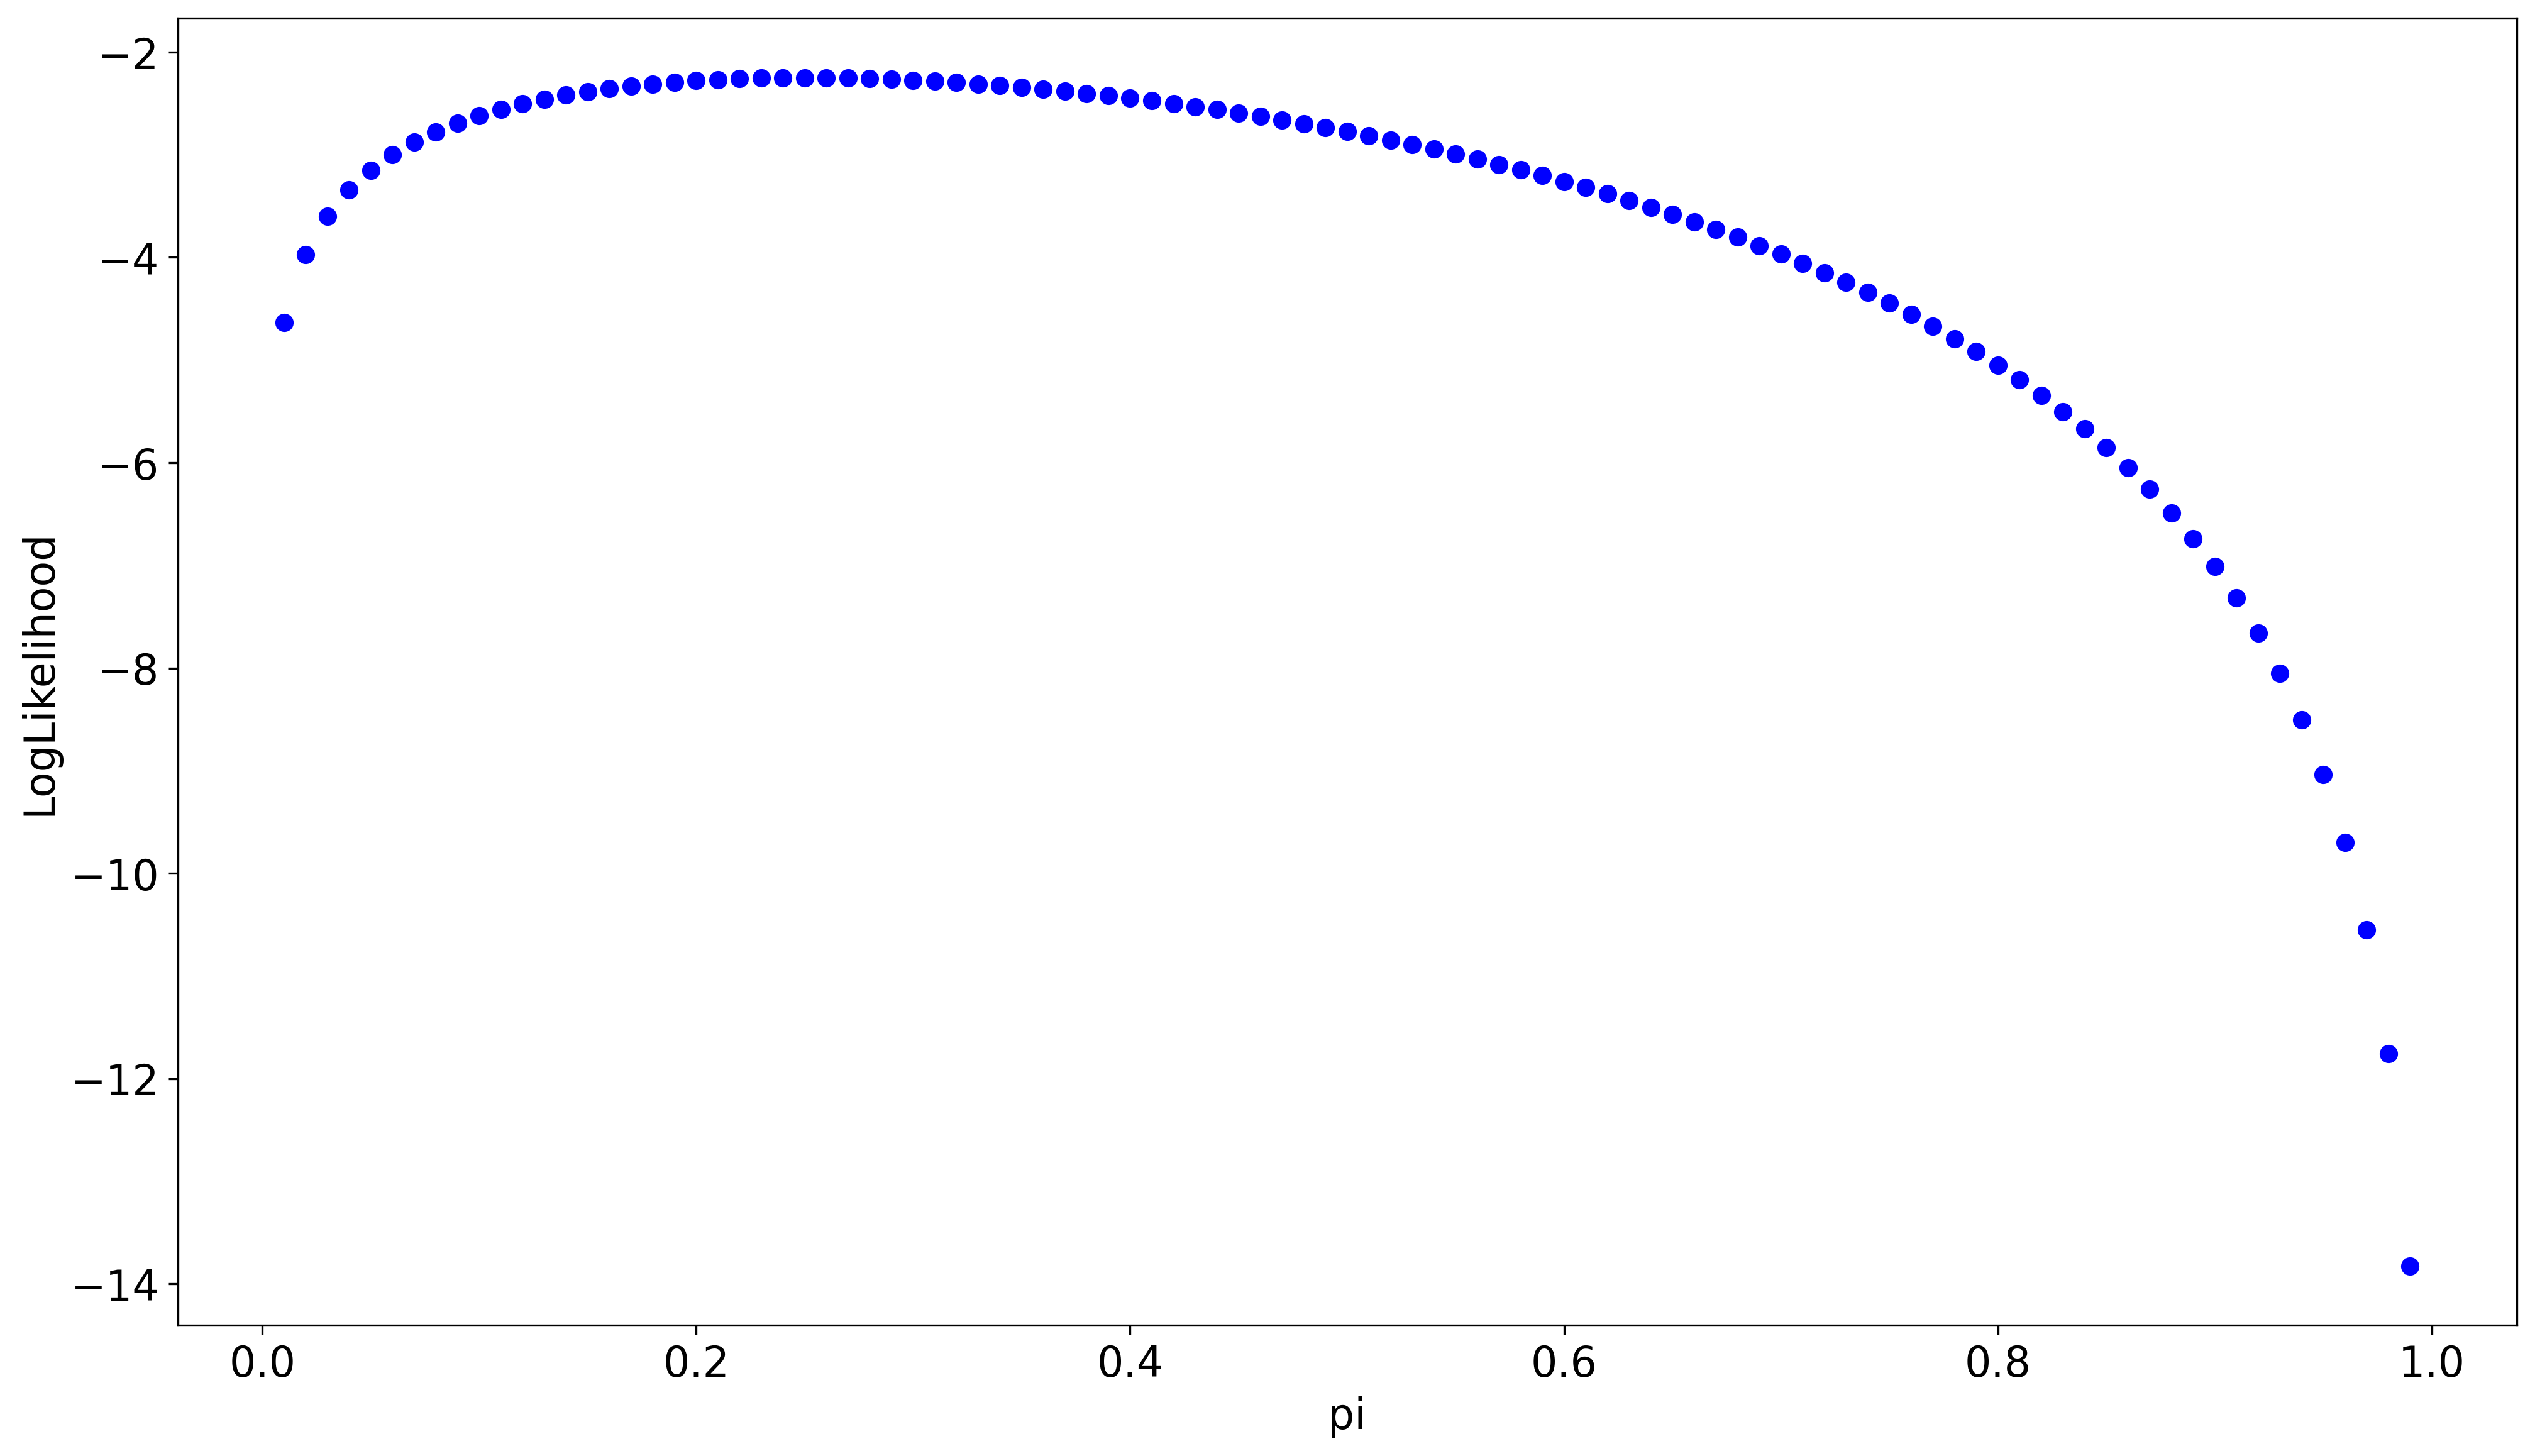

In [11]:
for pi_s in range(1, 100, 1):
    loglike_pi = fun_loglike1(pi_s / 100)
    plt.xlabel('pi')
    plt.ylabel('LogLikelihood')
    plt.plot(pi_s/100, loglike_pi, color='blue', marker='o')

In [12]:
def fun_loglike2(pi):
    loglike_indiv = d * np.log(pi) + (1-d) * (np.log(1-pi))
    neg_loglike = - np.sum(loglike_indiv)
    return neg_loglike

In [13]:
start = 0.1
minimize(fun_loglike2, start, method = 'Nelder-Mead', options={'disp': True})

Optimization terminated successfully.
         Current function value: 2.249341
         Iterations: 15
         Function evaluations: 30


 final_simplex: (array([[0.25      ],
       [0.25007813]]), array([2.24934058, 2.24934064]))
           fun: 2.249340578475233
       message: 'Optimization terminated successfully.'
          nfev: 30
           nit: 15
        status: 0
       success: True
             x: array([0.25])

In [14]:
d = np.array([0,0,1,1])
x = np.array([400, 300, 200, 100])

In [15]:
def fun_loglike3(beta):
    pd_pred = np.exp(beta * x) / (1 + np.exp(beta * x))
    loglike_indiv = d * np.log(pd_pred) + (1-d) * (np.log(1-pd_pred))
    loglike = np.sum(loglike_indiv)
    return loglike 

logL beta:
-3.51 -0.01
-3.29 -0.01
-3.08 -0.01
-2.9 -0.01
-2.74 -0.01
-2.62 -0.0
-2.53 -0.0
-2.5 -0.0
-2.52 -0.0
-2.61 -0.0
-2.77 0.0
-3.01 0.0
-3.32 0.0
-3.7 0.0
-4.13 0.0
-4.62 0.0
-5.14 0.01
-5.7 0.01
-6.28 0.01
-6.89 0.01


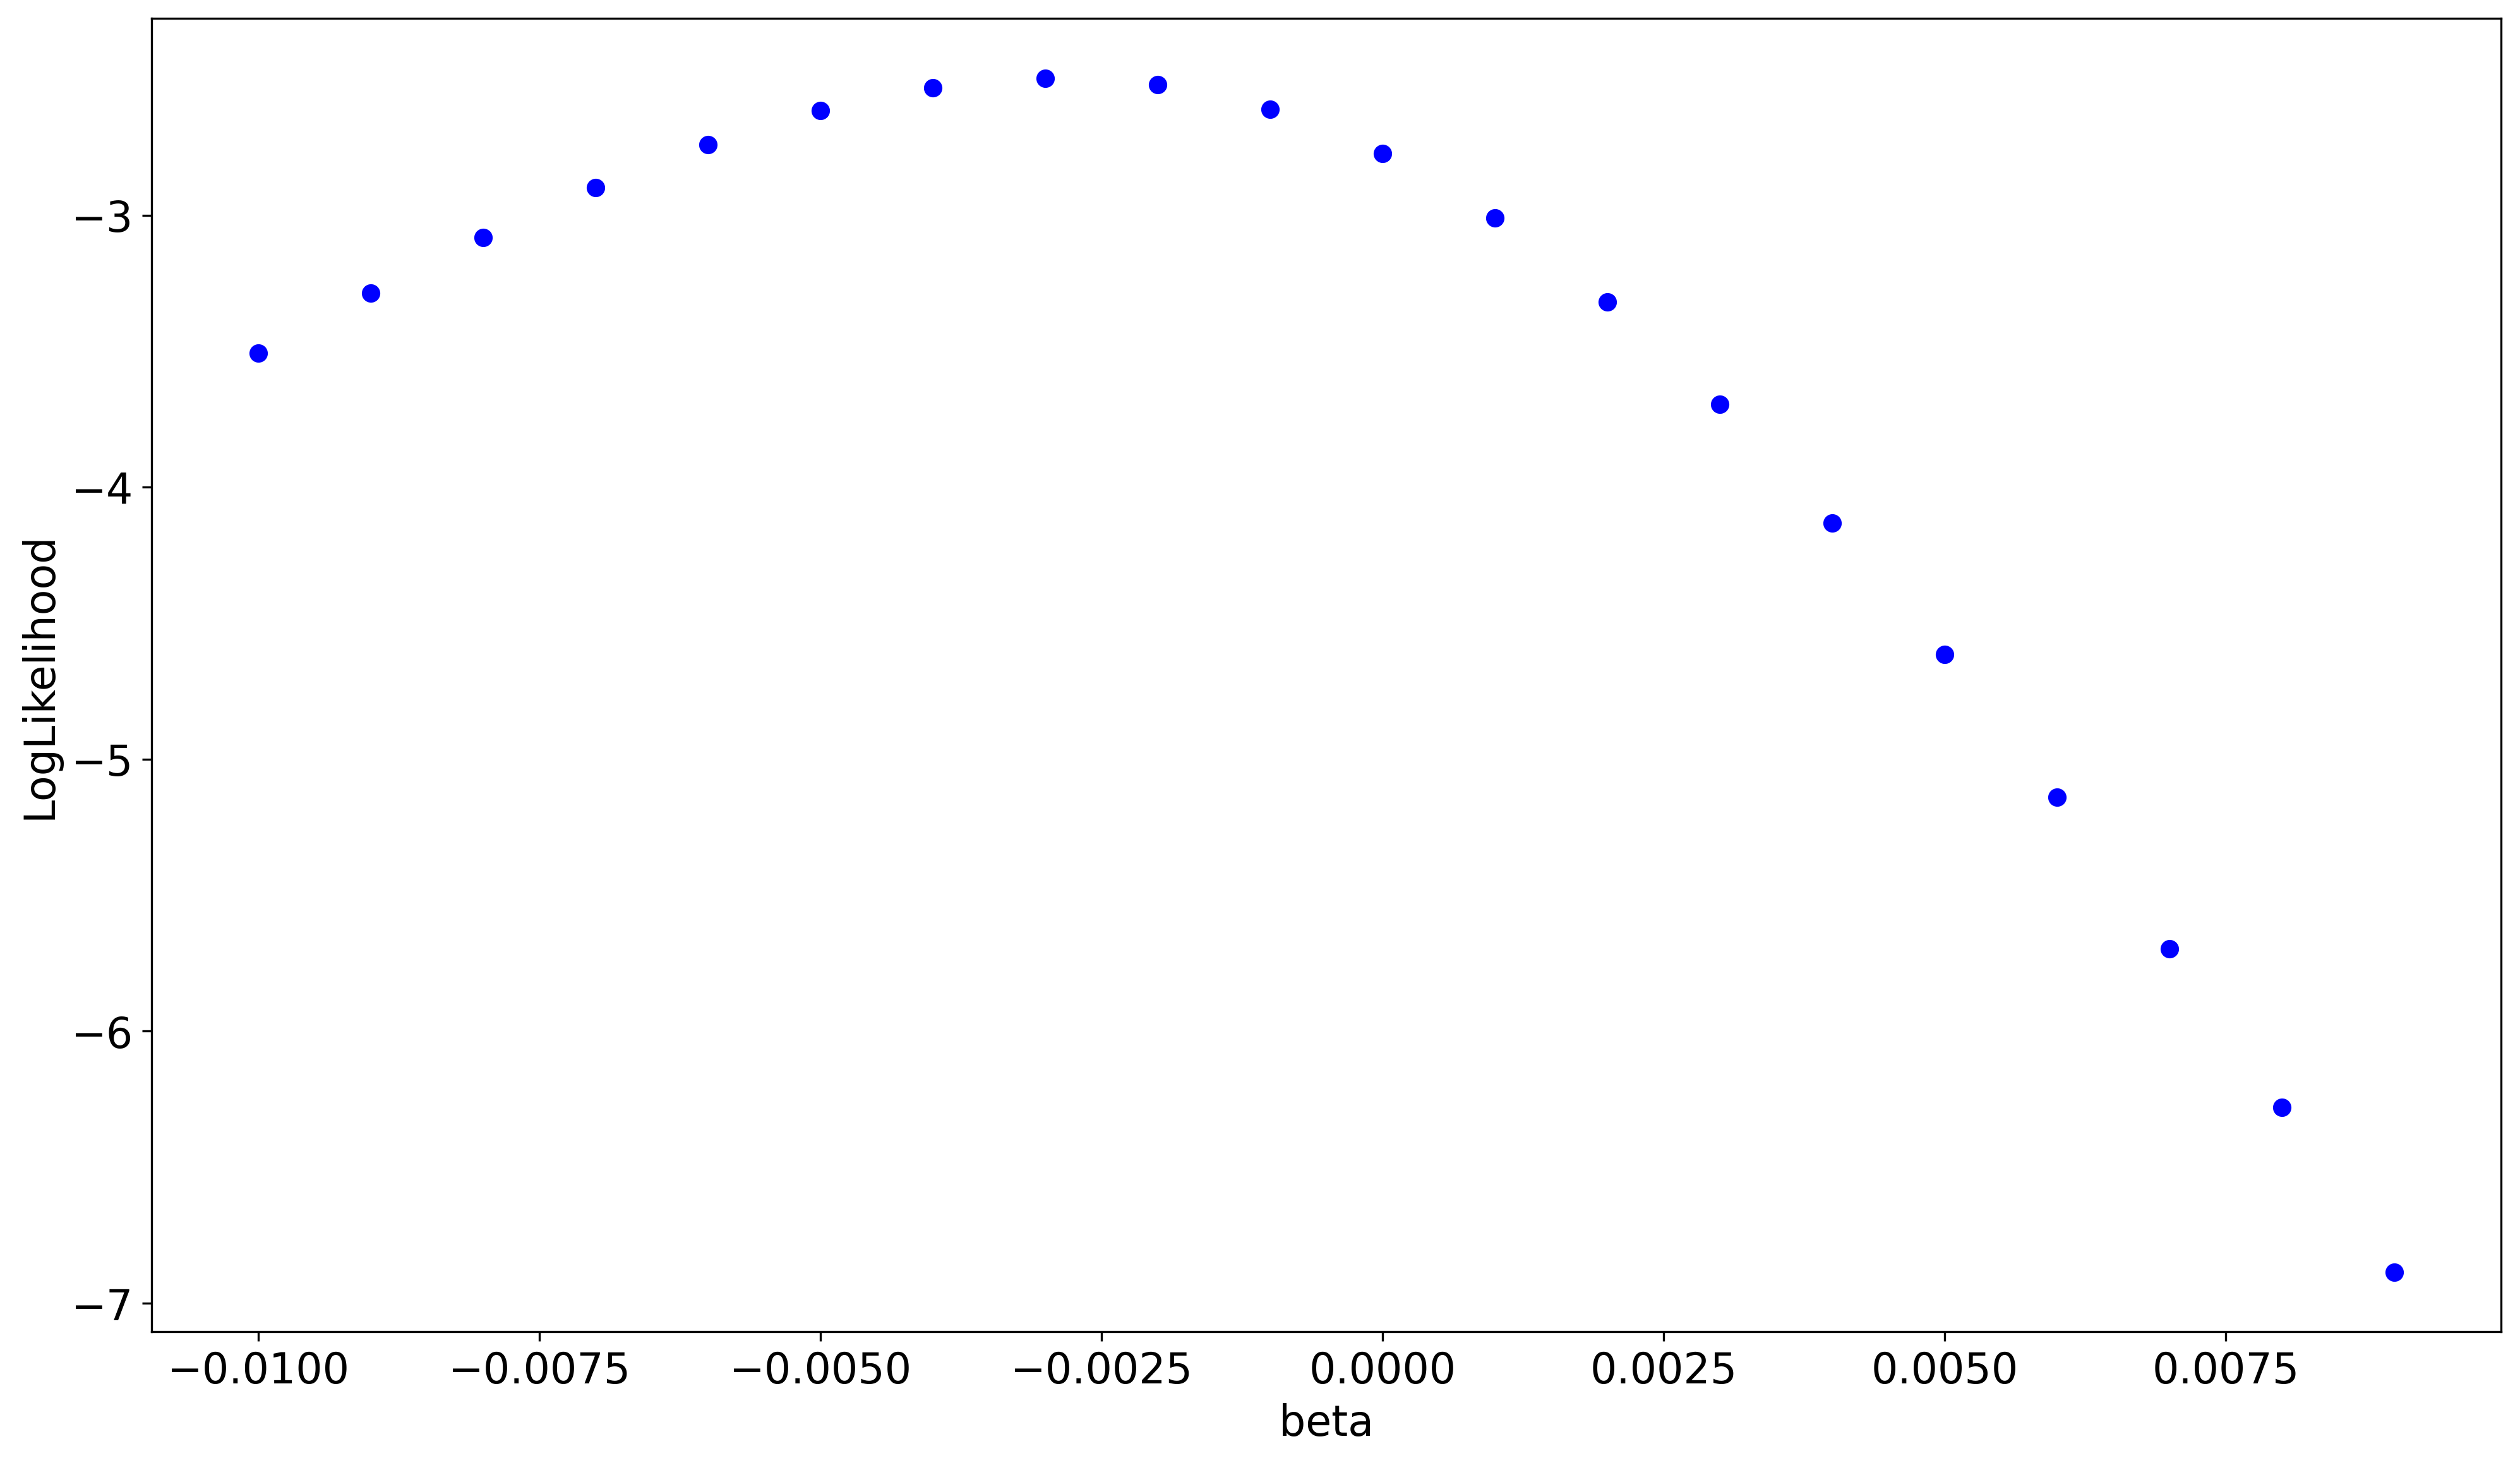

In [16]:
print('logL', 'beta:')
for beta_s in range(-10, 10, 1):
    loglike_beta = fun_loglike3(beta_s/1000)
    plt.xlabel('beta')
    plt.ylabel('LogLikelihood')
    plt.plot(beta_s/1000, loglike_beta, color='blue', marker='o')

    print(np.round(loglike_beta, 2), np.round(beta_s/1000,2))

In [17]:
beta_opt = -0.003
print('Linear predictor:', beta_opt * x)
print('PDs:', np.round(np.exp(beta_opt * x) / (1 + np.exp(beta_opt * x)), 2))

Linear predictor: [-1.2 -0.9 -0.6 -0.3]
PDs: [0.23 0.29 0.35 0.43]


In [18]:
def fun_loglike4(beta):
    pd_pred = np.exp(beta * x) / (1 + np.exp(beta * x)) 
    loglike_indiv = d * np.log(pd_pred) + (1-d) * (np. log(1-pd_pred))
    neg_loglike = - np.sum(loglike_indiv)
    return neg_loglike

In [20]:
start = 0 
minimize(fun_loglike4, start, method='Nelder-Mead', options={'disp': True})

Optimization terminated successfully.
         Current function value: 2.495831
         Iterations: 9
         Function evaluations: 18


 final_simplex: (array([[-0.002875  ],
       [-0.00290625]]), array([2.49583114, 2.4958565 ]))
           fun: 2.495831135080063
       message: 'Optimization terminated successfully.'
          nfev: 18
           nit: 9
        status: 0
       success: True
             x: array([-0.002875])

In [21]:
model_logit = sm.Logit(d, x)
results_logit = model_logit.fit()

print(results_logit.summary())

Optimization terminated successfully.
         Current function value: 0.623958
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                    4
Model:                          Logit   Df Residuals:                        3
Method:                           MLE   Df Model:                            0
Date:                Sat, 26 Jul 2025   Pseudo R-squ.:                 0.09982
Time:                        15:29:46   Log-Likelihood:                -2.4958
converged:                       True   LL-Null:                       -2.7726
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.0029      0.004     -0.703      0.482      -0.011       0.005


In [22]:
print('PDs:', np.round(results_logit.predict(x), 2))

PDs: [0.24 0.3  0.36 0.43]


In [23]:
data = data.dropna(subset=['time', 'default_time', 'FICO_orig_time'])

In [26]:
d = data['default_time']
def fun_loglike5(pi):
    loglike_indiv = d * np.log(pi) * (1-d) * (np.log(1-pi))
    neg_loglike = -np.sum(loglike_indiv)
    return neg_loglike

In [27]:
start = 0.05
minimize(fun_loglike5, start, method = 'Nelder-Mead', options={'disp': True})

Optimization terminated successfully.
         Current function value: -0.000000
         Iterations: 6
         Function evaluations: 17


 final_simplex: (array([[0.05      ],
       [0.05007813]]), array([-0., -0.]))
           fun: -0.0
       message: 'Optimization terminated successfully.'
          nfev: 17
           nit: 6
        status: 0
       success: True
             x: array([0.05])

In [28]:
x = sm.add_constant(data['FICO_orig_time'], prepend=True)  
model_logit = sm.Logit(d, x)  
results_logit = model_logit.fit()  
print(results_logit.summary()) 

Optimization terminated successfully.
         Current function value: 0.113822
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:           default_time   No. Observations:                62178
Model:                          Logit   Df Residuals:                    62176
Method:                           MLE   Df Model:                            1
Date:                Sat, 26 Jul 2025   Pseudo R-squ.:                 0.01168
Time:                        15:35:42   Log-Likelihood:                -7077.2
converged:                       True   LL-Null:                       -7160.9
Covariance Type:            nonrobust   LLR p-value:                 2.992e-38
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.6743      0.229     -2.950      0.003      -1.122      -0.226
FICO_orig_time   

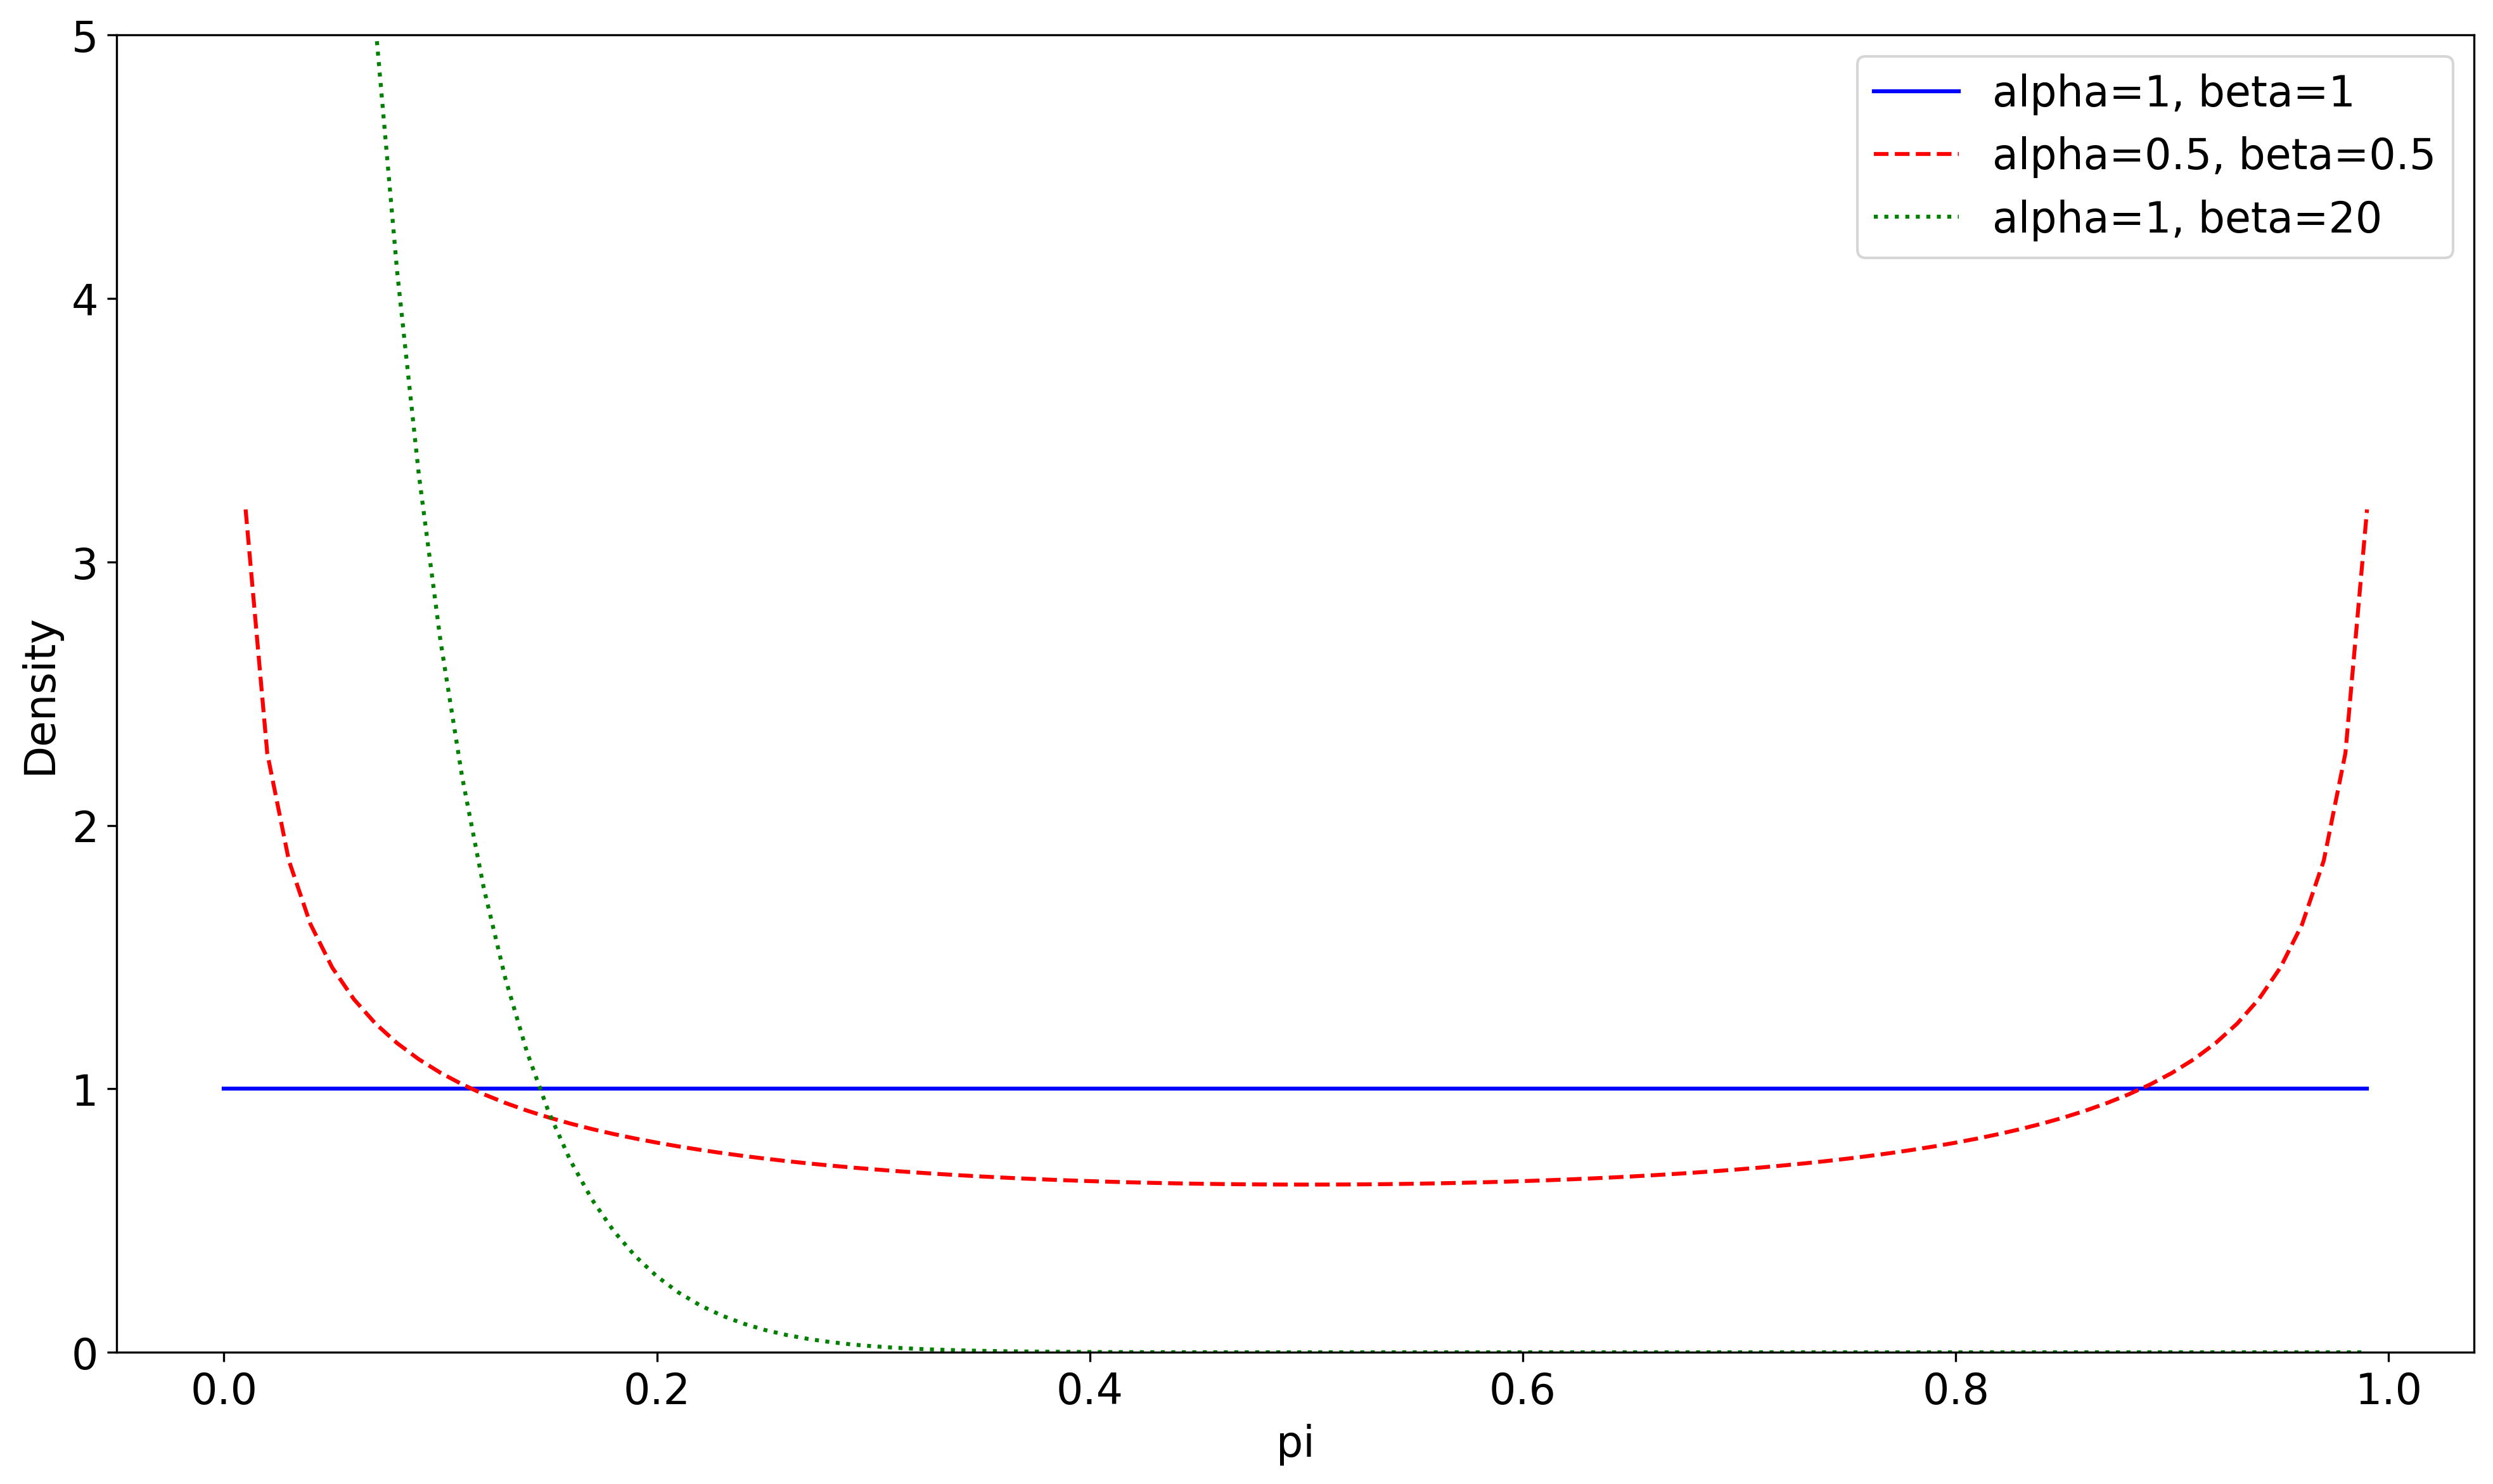

In [29]:
pi = np.arange(0, 1, 0.01)

alpha1, beta1 = 1, 1 
beta_pdf1 = beta.pdf(pi, alpha1, beta1)
alpha2, beta2 = 0.5, 0.5
beta_pdf2 = beta.pdf(pi, alpha2, beta2)
alpha3, beta3 = 1, 20 
beta_pdf3 = beta.pdf(pi, alpha3, beta3)

plt.plot(pi, beta_pdf1, marker='', color='blue', label='alpha=1, beta=1', ls='solid')
plt.plot(pi, beta_pdf2, marker='', color='red', label='alpha=0.5, beta=0.5', ls='dashed')
plt.plot(pi, beta_pdf3, marker='', color='green', label='alpha=1, beta=20', ls='dotted')

plt.xlabel('pi')
plt.ylim(0,5)
plt.ylabel('Density')
plt.legend(loc='best')

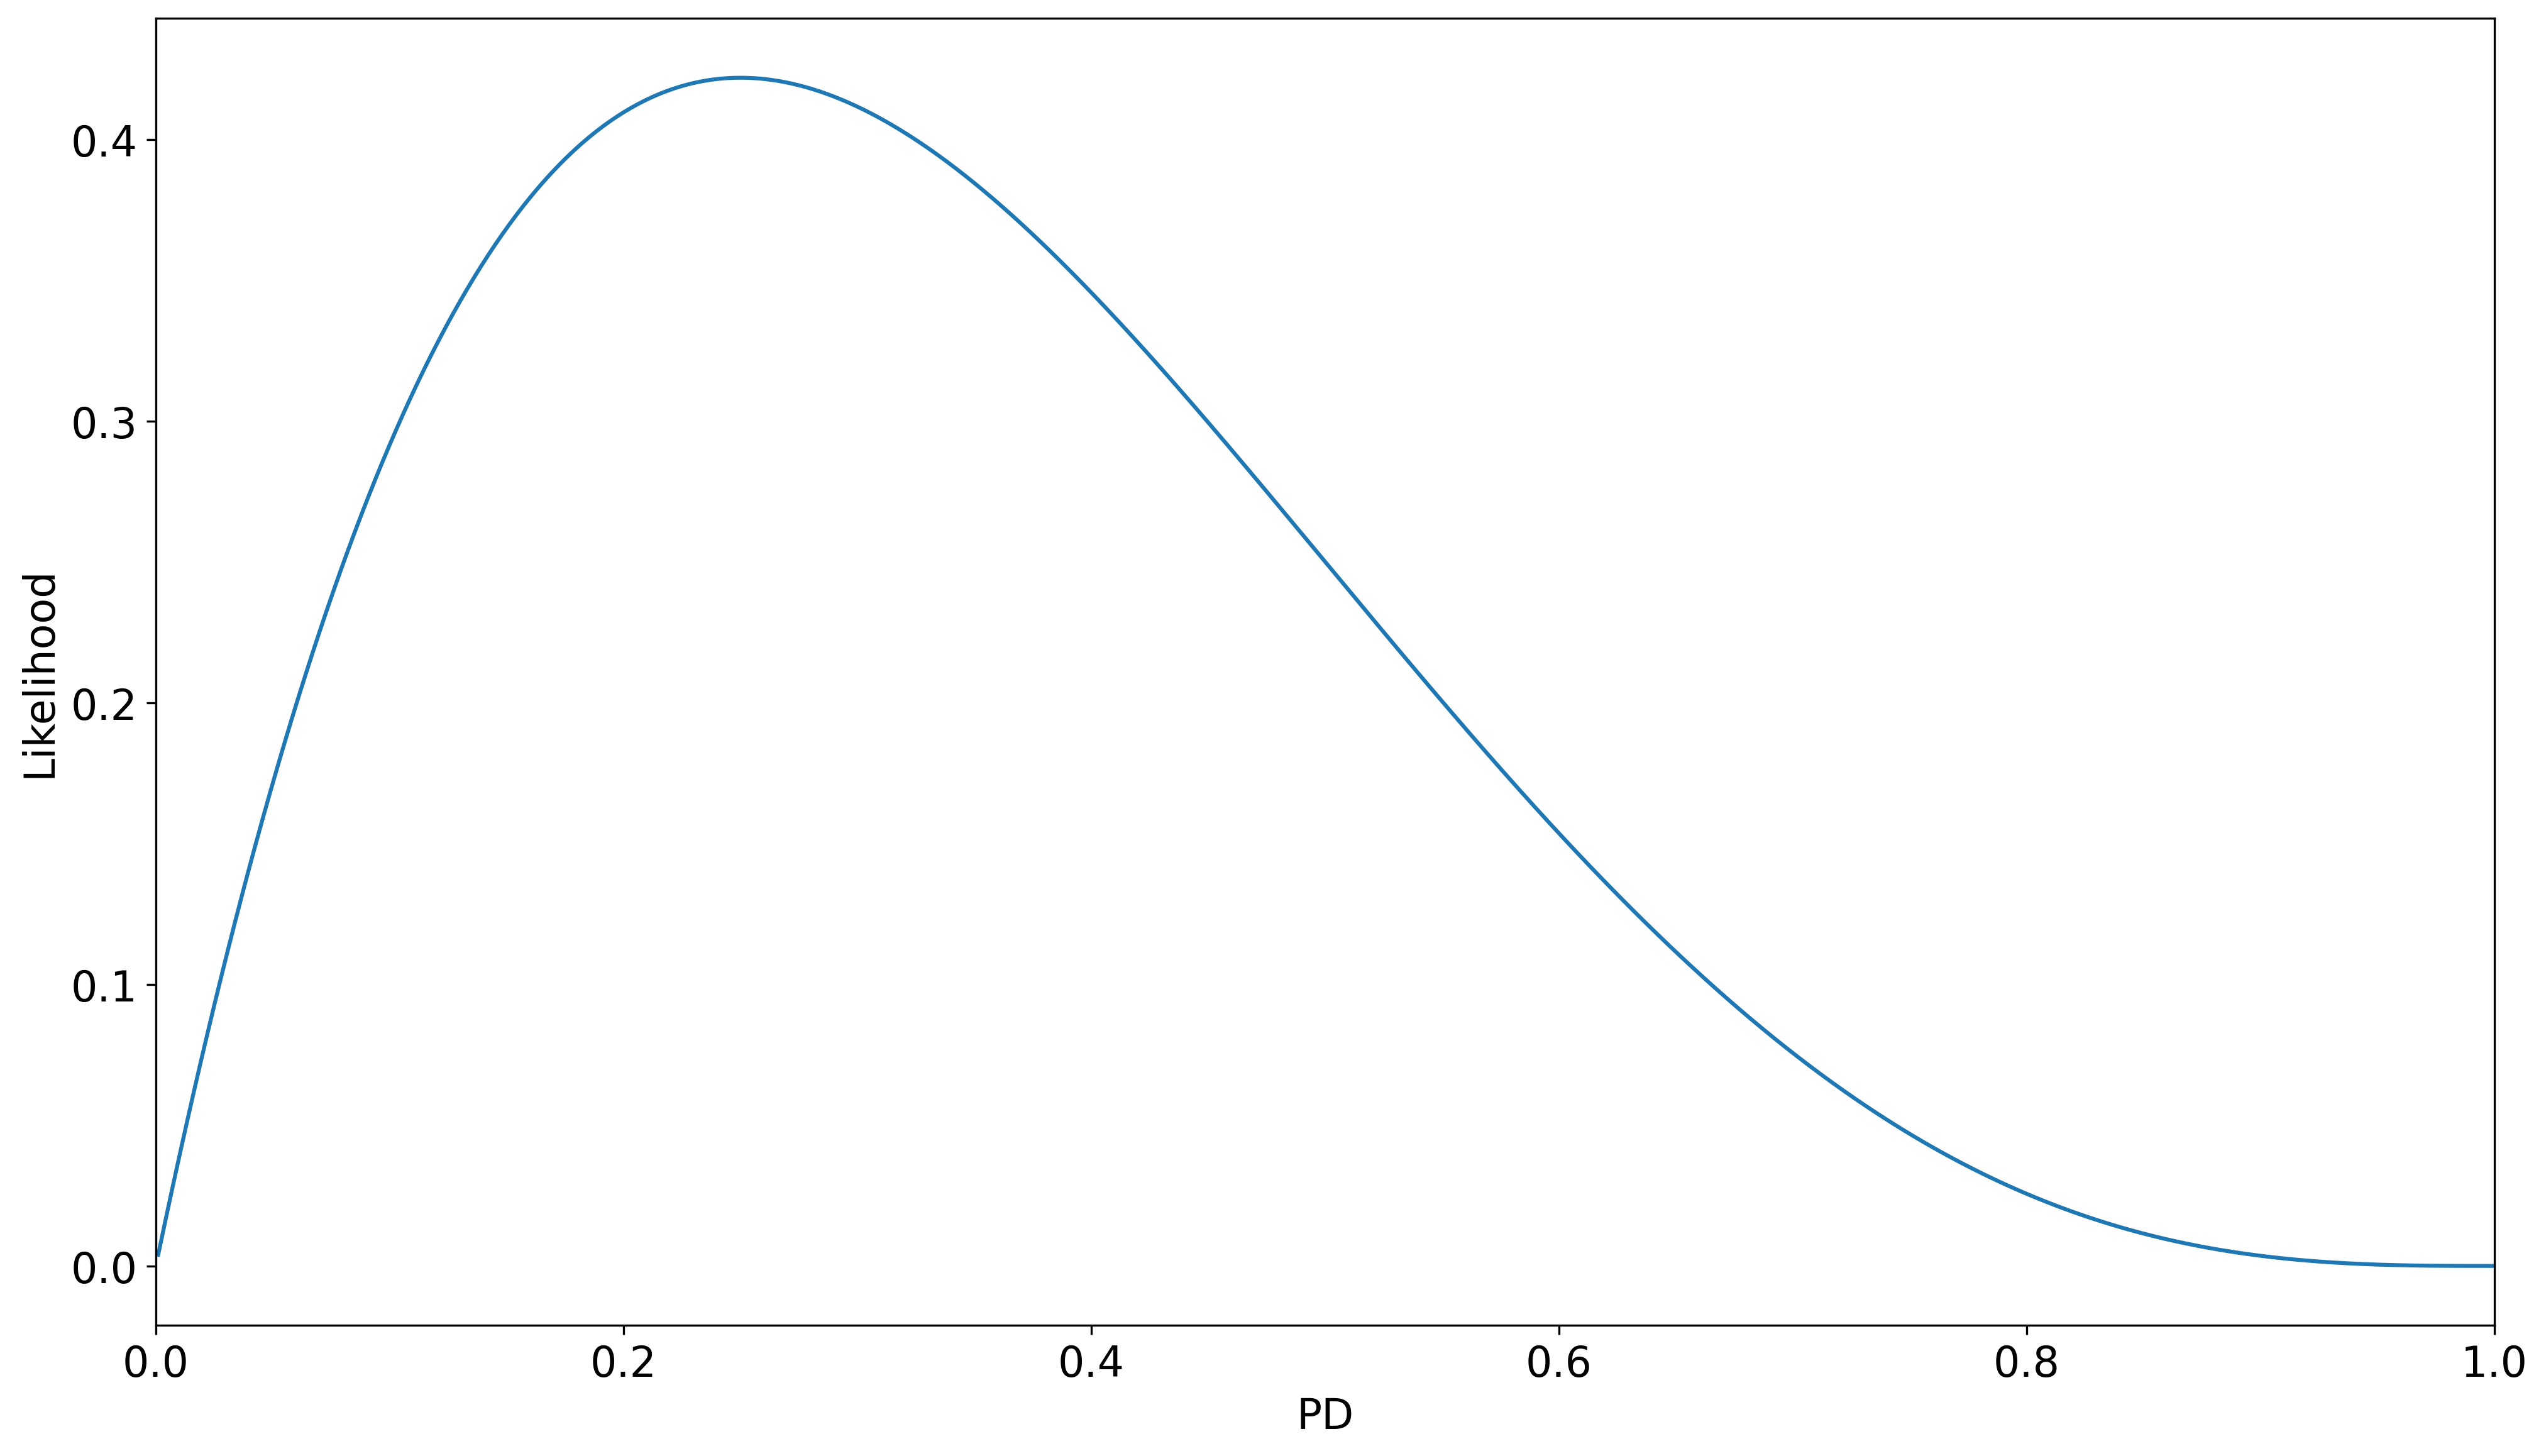

In [30]:
d = [0, 0, 0, 1]
pi = np.arange(1,1000)/1000

likelihood = binom.pmf(np.sum(d), n=len(d), p=pi, loc=0)

plt.plot(pi, likelihood, alpha=1, label='Likelihood')
plt.xlim(0,1)
plt.xlabel('PD')
plt.ylabel('Likelihood')
plt.show()

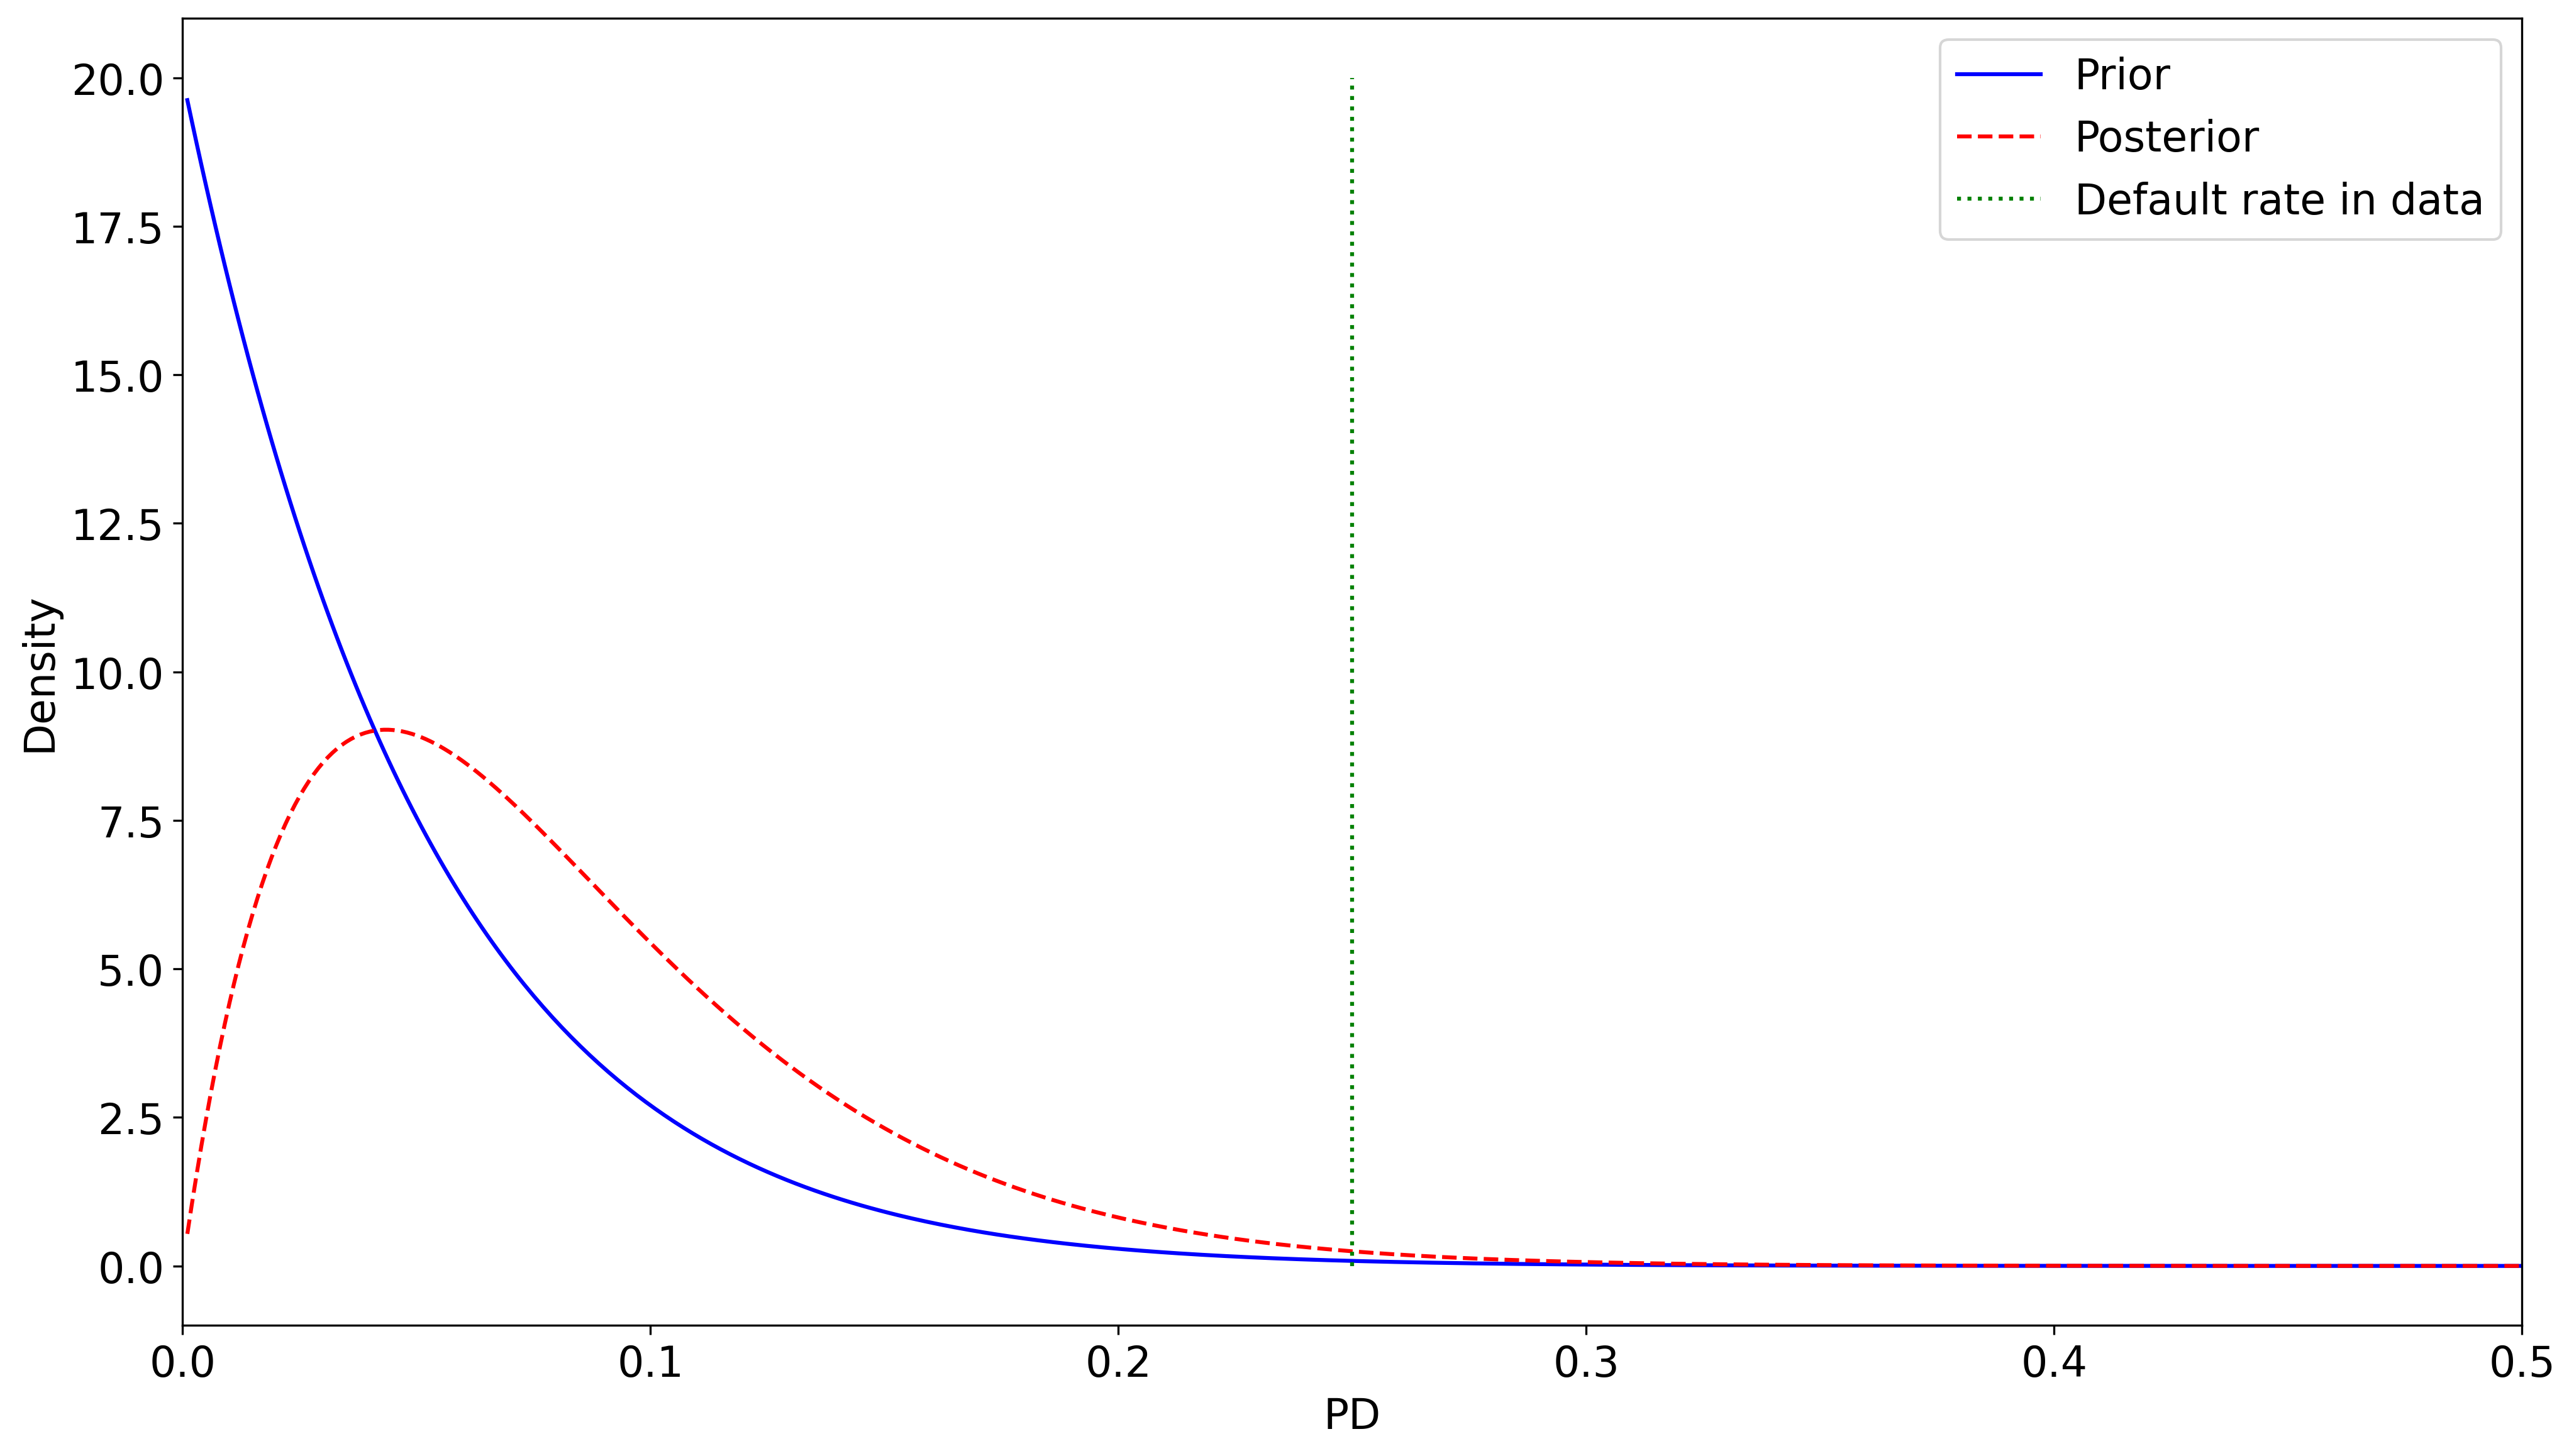

In [32]:
alpha_prior = 1
beta_prior = 20

prior = beta.pdf(pi, alpha_prior, beta_prior, loc=0, scale=1)
alpha_post = alpha_prior + np.sum(d)
beta_post = beta_prior + len(d) - np.sum(d)
posterior = beta.pdf(pi, alpha_post, beta_post, loc=0, scale=1)

plt.plot(pi, prior, color='blue', ls='solid', label='Prior')
plt.plot(pi, posterior, color='red', ls='dashed', label='Posterior')
plt.plot([np.mean(d), np.mean(d)], [0,20], color='green', ls='dotted', label='Default rate in data')
plt.xlim(0,0.5)
plt.xlabel('PD')
plt.ylabel('Density')
plt.legend(loc='best')
plt.legend()
plt.show()

In [33]:
data_bayes = data.sample(100, random_state=12345)

Default rate: 0.06
# of defaults: 6
# of observations: 100


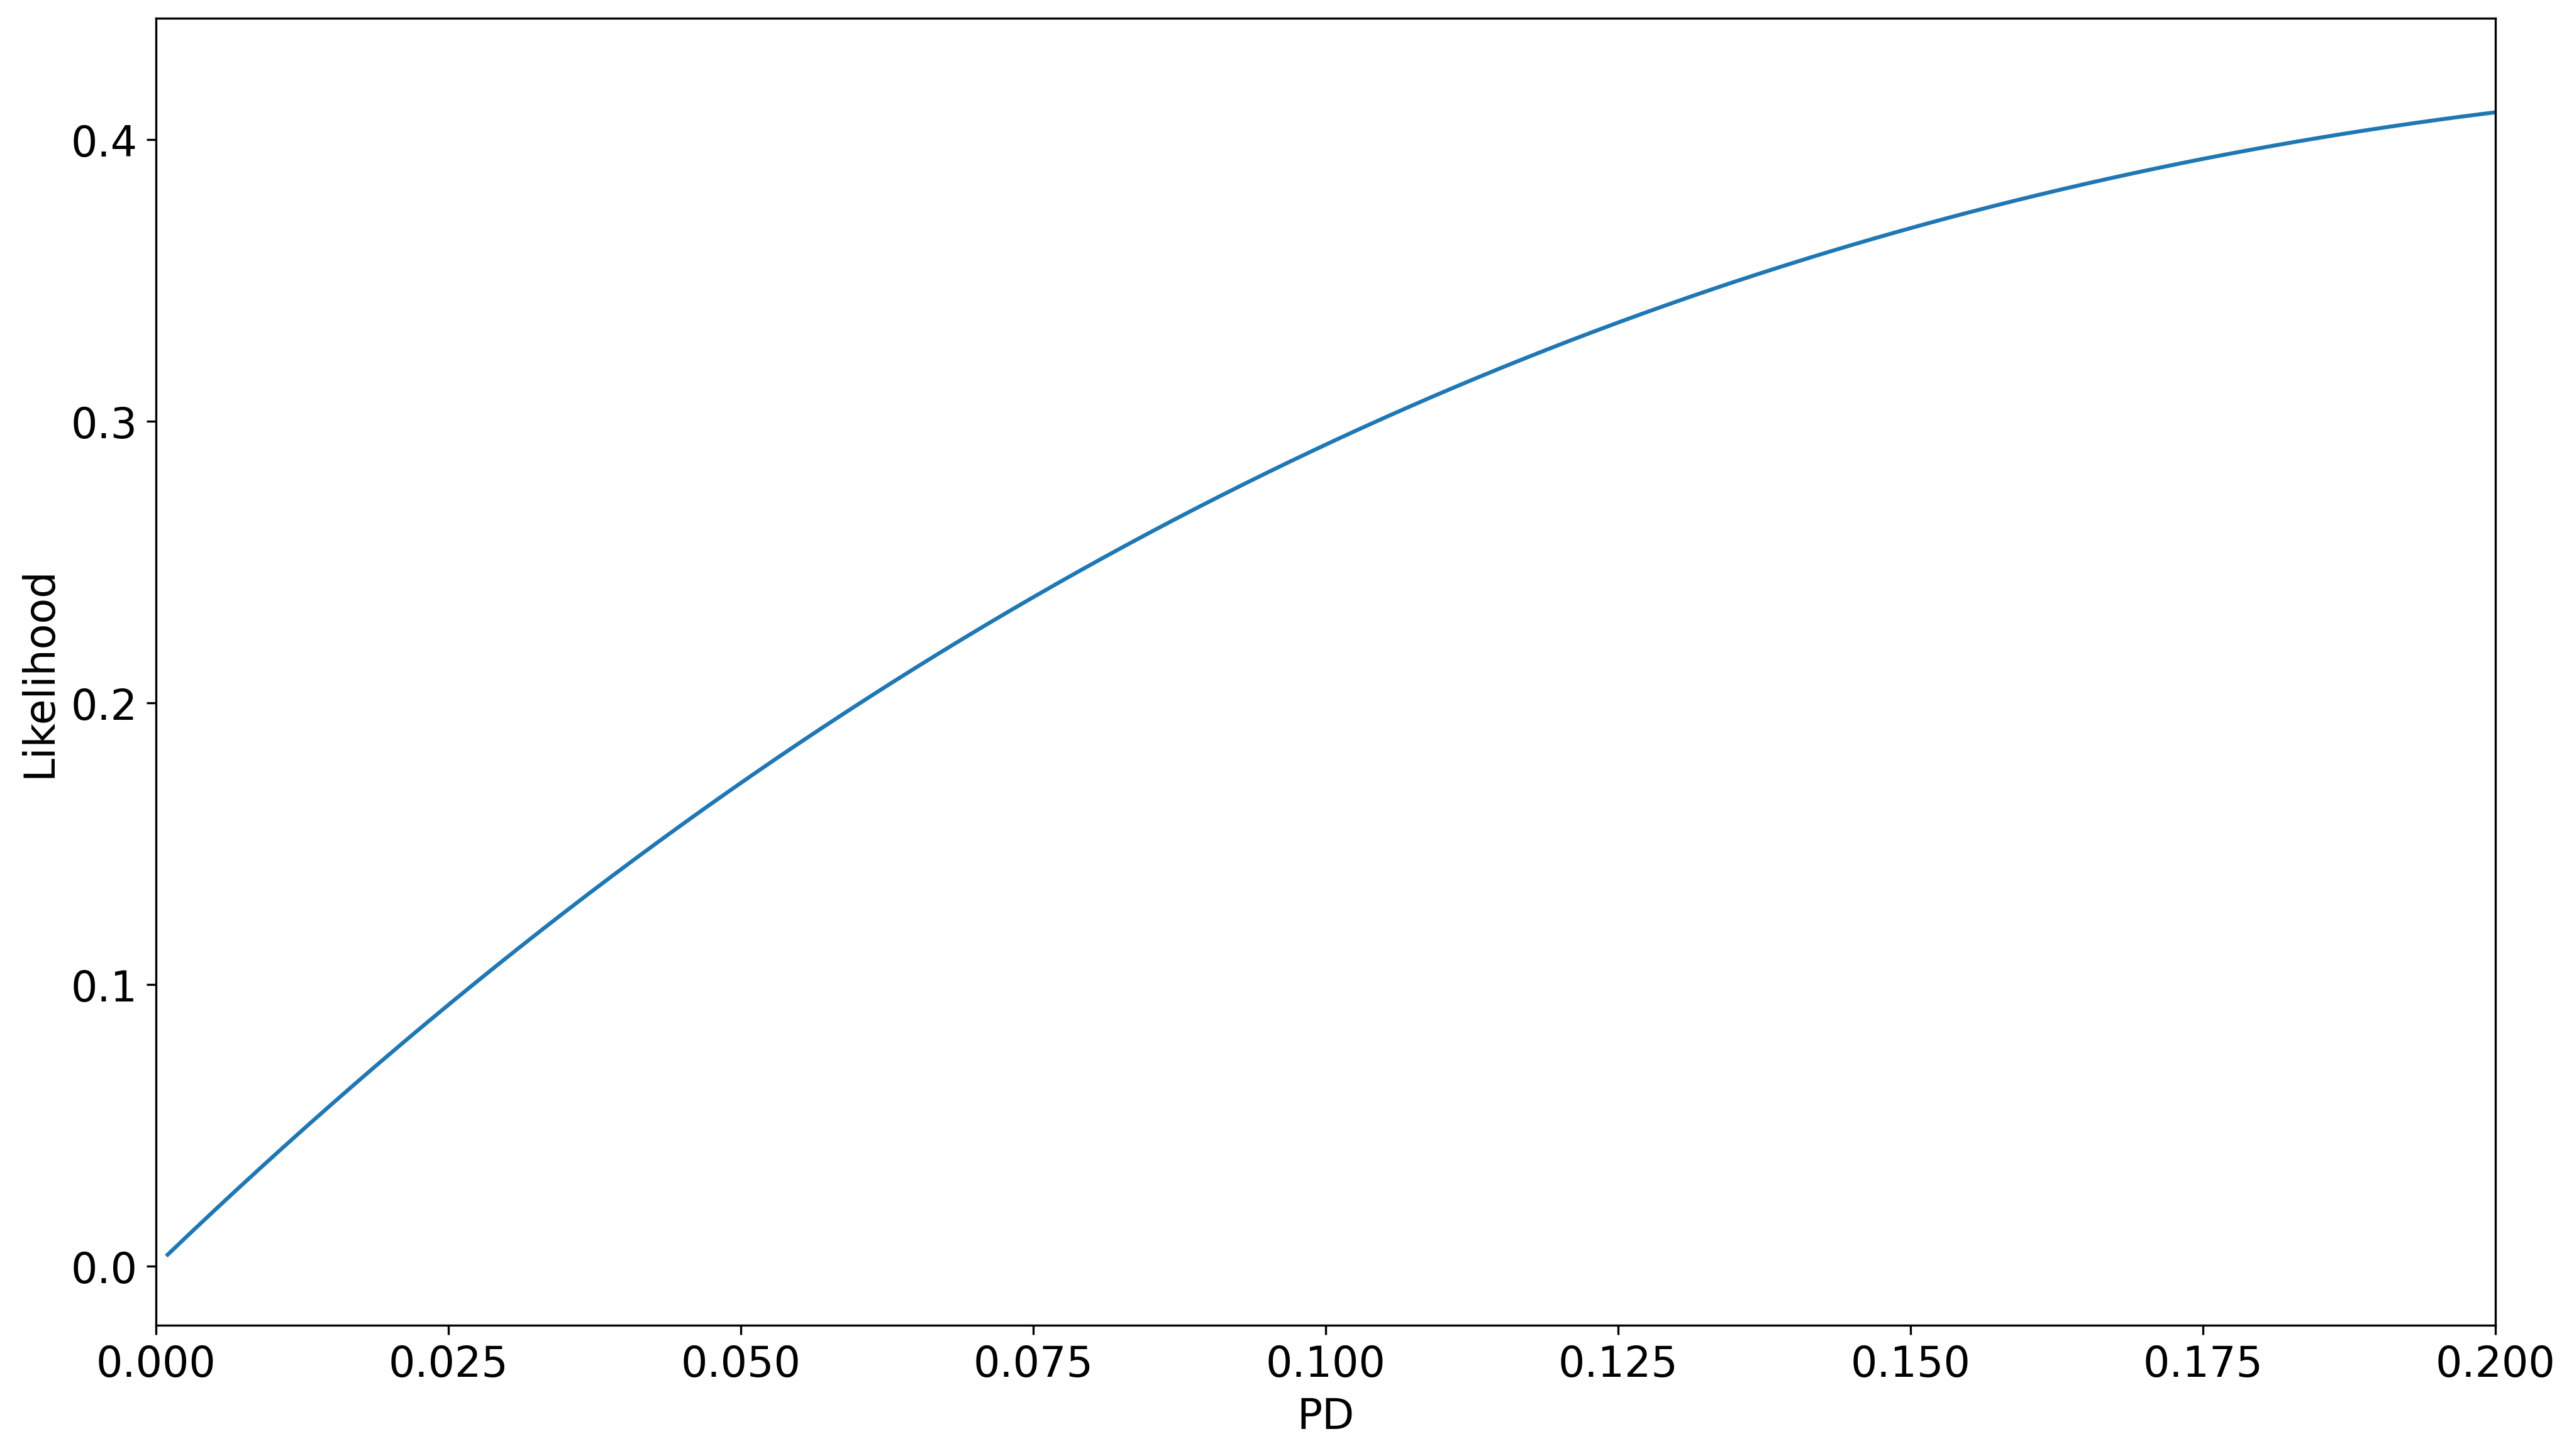

In [34]:
y = data_bayes['default_time']

print('Default rate:', np.mean(y))
print('# of defaults:', np.sum(y))
print('# of observations:', len(y))

pi = np.arange(1, 1000)/1000

likelihood - binom.pmf(np.sum(y), n=len(y), p=pi, loc=0)
plt.plot(pi, likelihood, alpha=1)
plt.xlim(0,0.2)
plt.xlabel('PD')
plt.ylabel('Likelihood')
plt.show()

alpha posterior: 7
beta posterior: 114
posterior mean: 0.0579


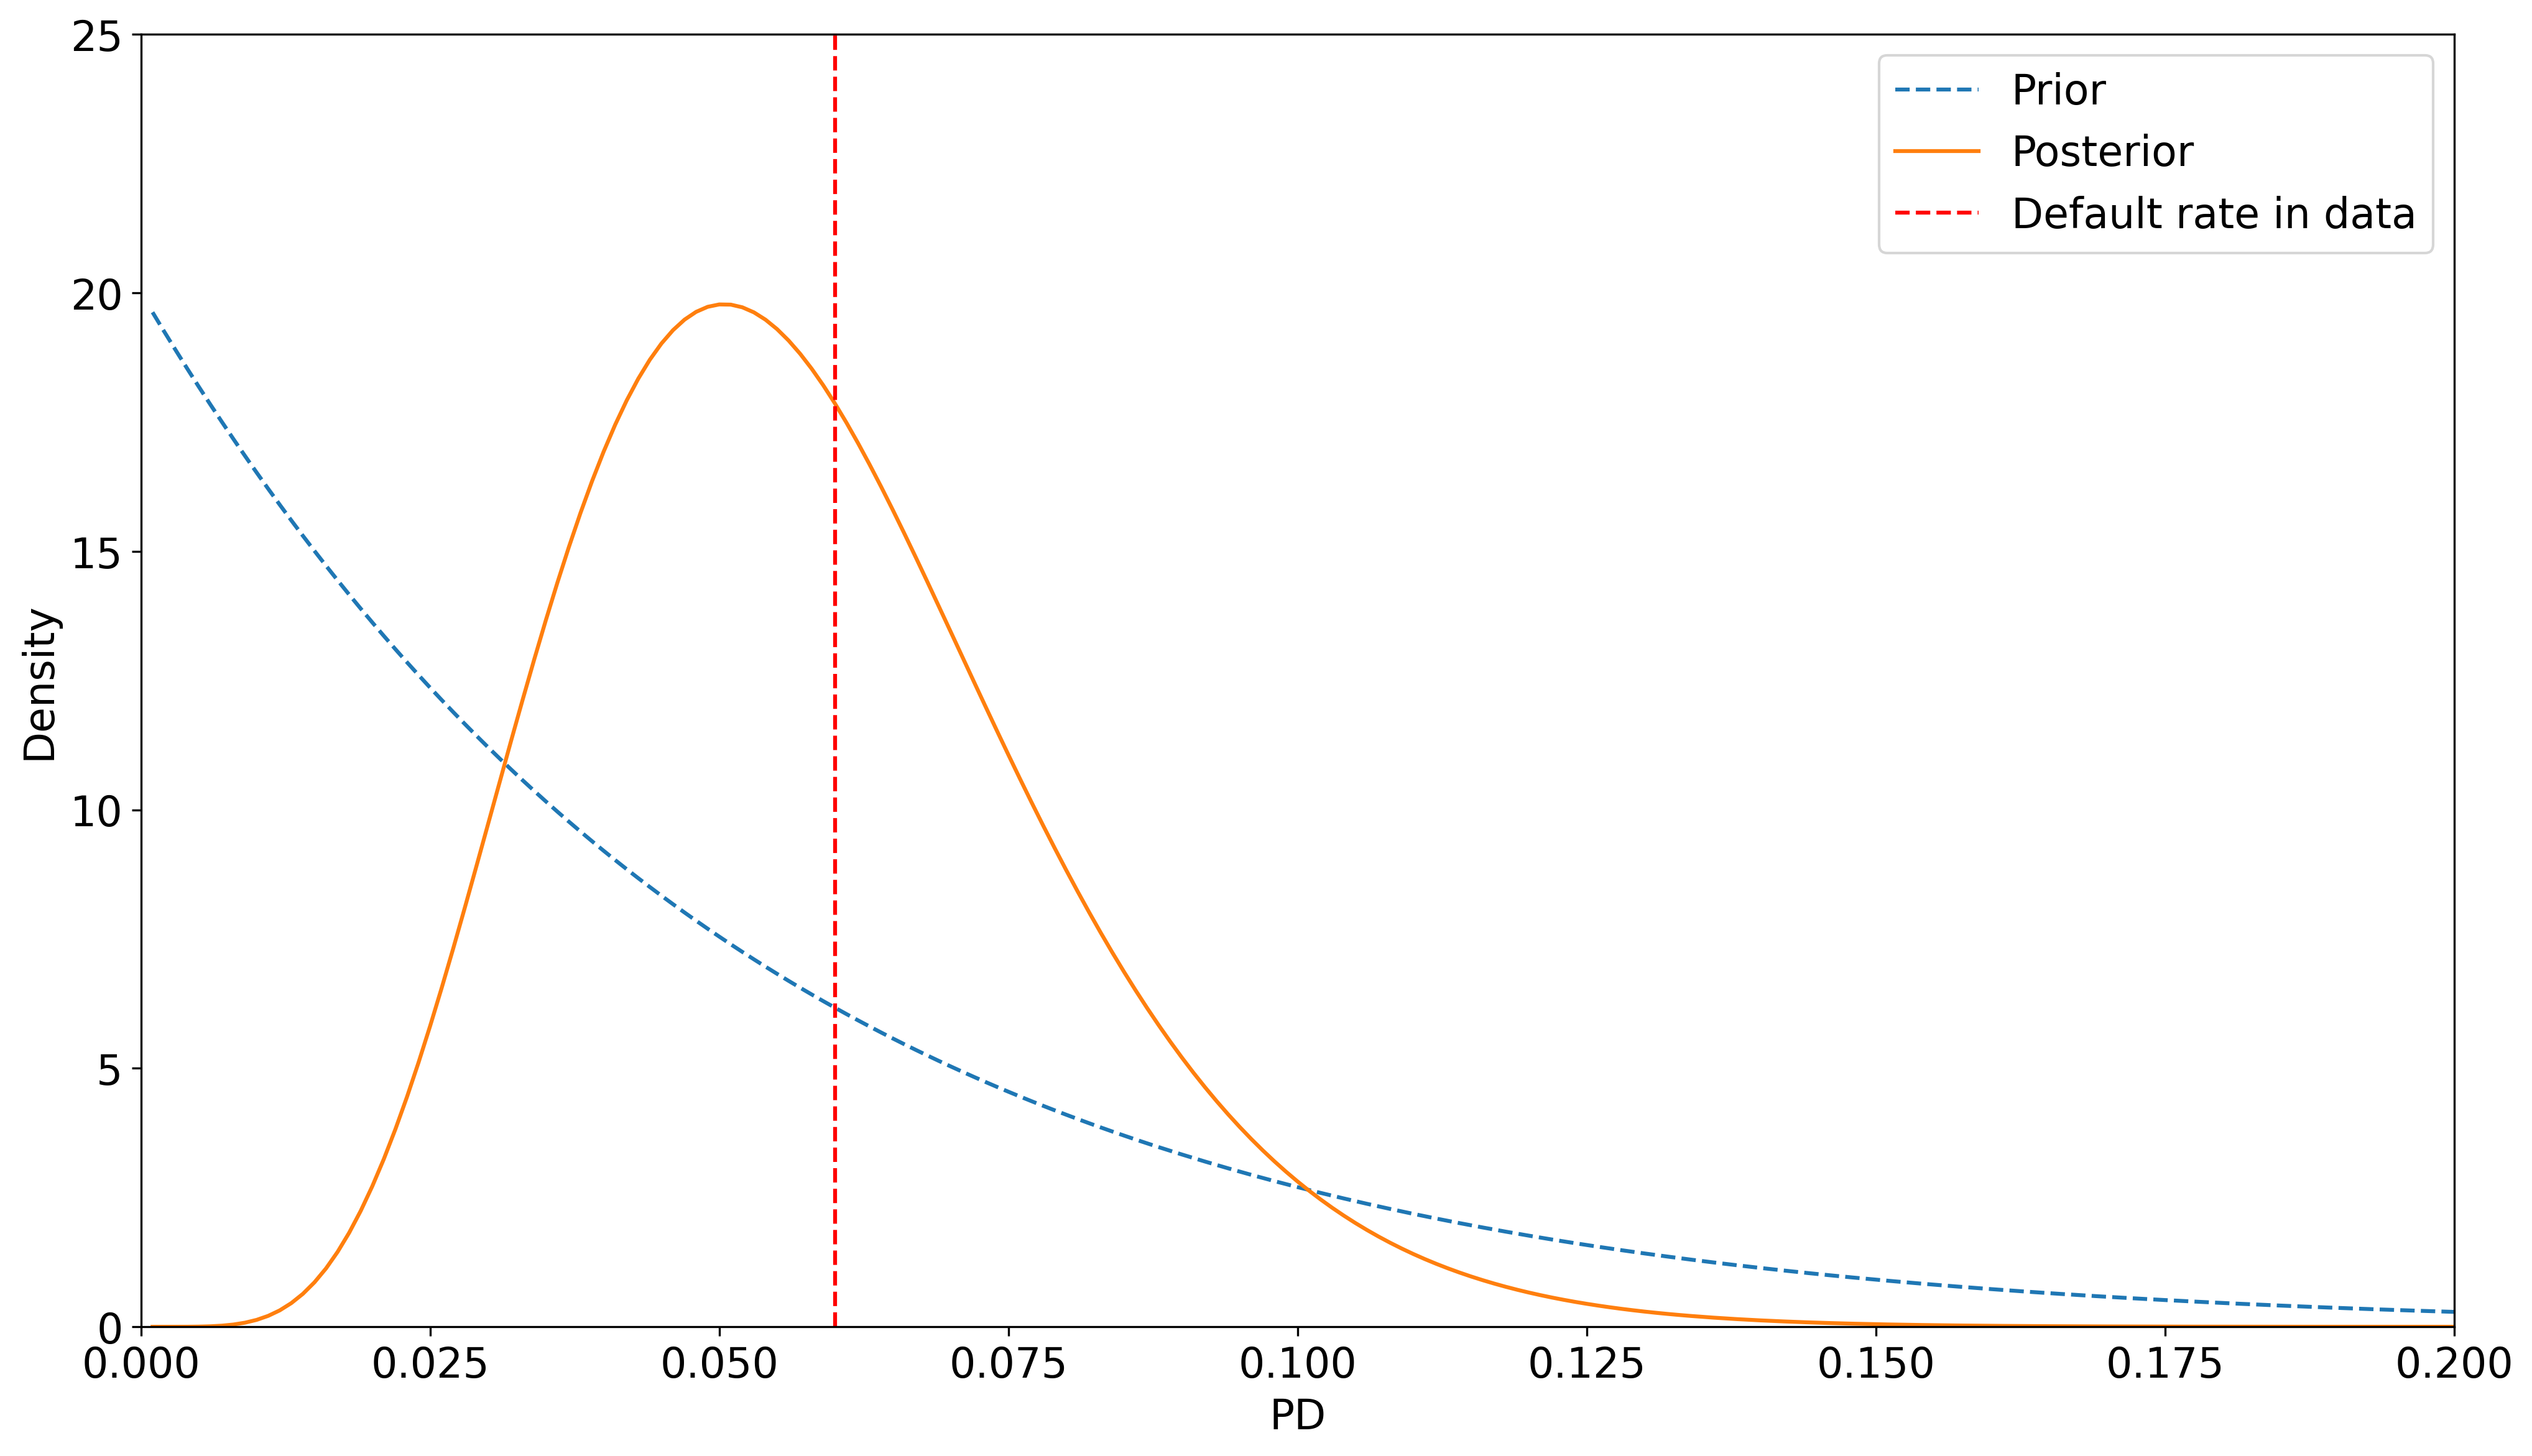

In [36]:
alpha_prior = 1  
beta_prior = 20  
prior = beta.pdf(pi, alpha_prior, beta_prior, loc=0, scale=1)  

alpha_post = alpha_prior + np.sum(y)  
beta_post = beta_prior + len(y) - np.sum(y)  
posterior = beta.pdf(pi, alpha_post, beta_post, loc=0, scale=1)  
posterior_mean = alpha_post/(alpha_post + beta_post)  

print('alpha posterior:', alpha_post)  
print('beta posterior:', beta_post)  
print('posterior mean:', posterior_mean.round(decimals=4))  
plt.plot(pi, prior, label="Prior", linestyle='dashed')  
plt.plot(pi, posterior, label="Posterior")  
plt.plot([np.mean(y), np.mean(y)], [0, 90], linestyle='dashed', color='red', label='Default rate in data')
plt.xlim(0,0.2)  
plt.ylim(0,25)  
plt.xlabel('PD')  
plt.ylabel('Density')  
plt.legend(loc='best')  
plt.legend()  
plt.show() 

In [37]:
with pm.Model() as mdl_PD:
    PD = pm.Beta('PD', alpha_prior, beta_prior)
    likelihood = pm.Binomial('likelihood', n=1, p=PD, observed=y)

In [38]:
print('Running on PyMC3 v{}'.format(pm.__version__))
with mdl_PD:
    step = pm.NUTS()
    traces_PD = pm.sample(2000, step, tune=2000, progressbar=False, random_seed=12345)

Running on PyMC3 v3.11.6


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [PD]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 53 seconds.


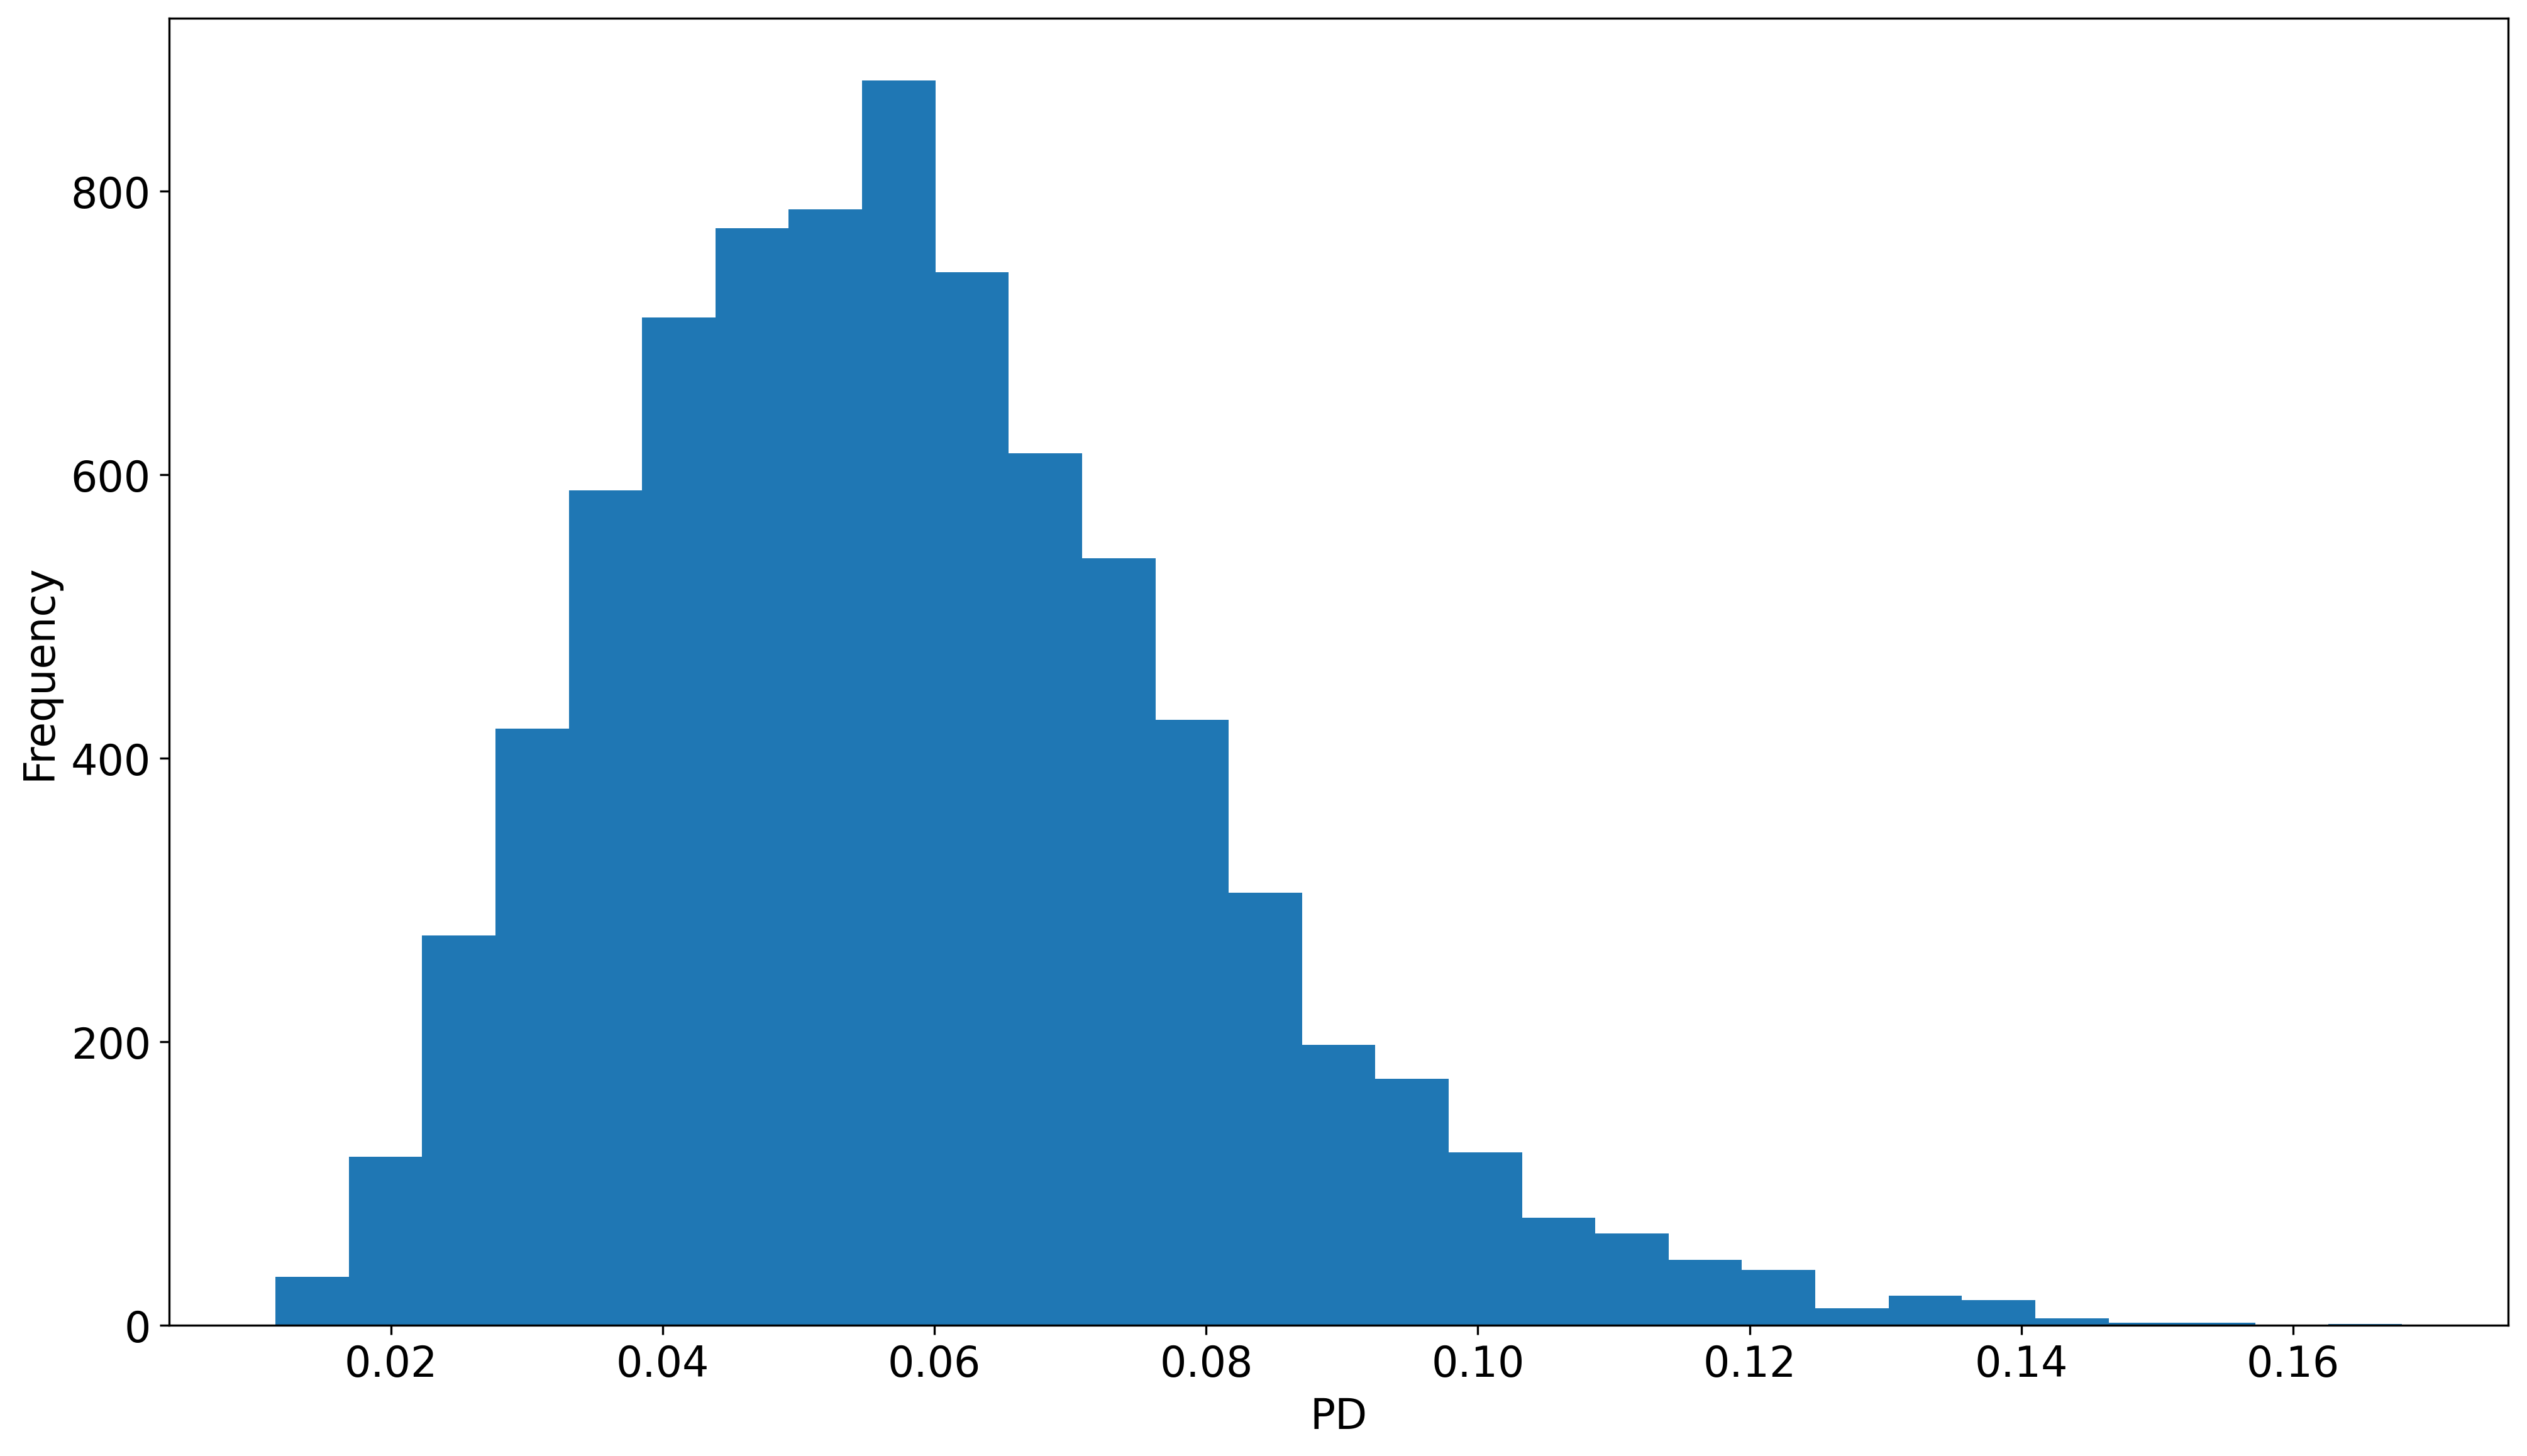

In [39]:
plt.hist(traces_PD['PD'], bins=29)
plt.xlabel('PD')
plt.ylabel('Frequency')
plt.show()

In [40]:
print(pd.DataFrame(traces_PD['PD']).describe()) 

                 0
count  8000.000000
mean      0.058505
std       0.021790
min       0.011494
25%       0.042781
50%       0.056457
75%       0.071222
max       0.168013
